# Bayesian optimization using Kriging

Mathias LOMMEL

5MA

Analyse d'incertitudes et de sensibilité en ingénierie

### Importation des librairies

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

import time
from IPython.display import clear_output
from scipy.stats import norm

from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import ConstantKernel, RBF, ExpSineSquared, Matern, WhiteKernel

from matplotlib.animation import FuncAnimation
import networkx as nx
from matplotlib.animation import FFMpegWriter

## Cadre d'étude

### Fonction d'étude

In [ ]:
# Définition de la fonction d'étude
def f(x):
    """
    Définition de la fonction d'étude.

    Entrée :
        - x : Float - Point où calculer f

    Sortie :
        - y : Float - Valeur de la fonction au point donné
    """
    y = np.exp(-((4*x-2)*25+40)**2/350)*20-np.exp(-((4*x-2)*25-10)**2/50)*5+np.sin(((4*x-2)*25+50)/80)*25-19
    return y

kernel_f = ConstantKernel(constant_value=25.0) * RBF(length_scale=0.5, length_scale_bounds=(1e-6, 1e5))

Text(0.5, 1.0, 'Affichage de la fonction f sur [0,1]')

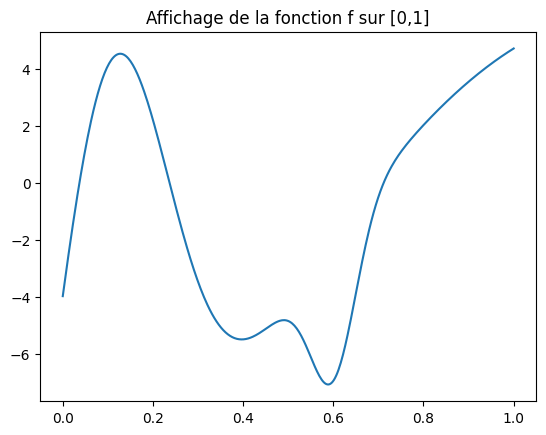

In [ ]:
# Grille d'abscisses
x = np.linspace(0,1,400)

# Affichage graphique
plt.plot(x,f(x),label="Fonction f")
plt.title("Affichage de la fonction f sur [0,1]")

### Prédiction par Krigeage

In [ ]:
def fit_gp(pXp,Z,x,kernel,alpha,restart_optimizer):
    """
    Approximation de la fonction f par Krigeage.

    Entrées :
        - pXp    : Array  - Plan d'expérience (points connus)
        - Z      : Array  - Valeurs de la fonction sur le plan d'expérience
        - x      : Array  - Valeurs où nous souhaitons interpoler la fonction f
        - kernel : Kernel - Noyau de covariance de la fonction f
        - alpha  : Float  - Coefficient de régularisation diagonale

    Sorties :
        - y_hat : Array - Valeurs interpolées de f sur x
        - s_hat : Array - Variance de l'estimation en tout point
    """
    # Création du modèle de régression par processus Gaussien
    gp = GaussianProcessRegressor(kernel=kernel,n_restarts_optimizer=restart_optimizer,alpha=alpha)
    # Ajustement du modèle aux données
    gp.fit(pXp,Z)
    # Prédiction du modèle sur l'intervalle d'étude
    y_hat, s_hat = gp.predict(x,return_std=True)

    return y_hat, s_hat

In [ ]:
def display_gp(pXp,Z,x,y_hat,s):
    """
    Affiche le résultat de l'interpolation de la fonction f par Krigeage.

    Entrée :
        - pXp   : Array - Plan d'expérience
        - Z     : Array - Valeurs de la fonction f sur le plan d'expérience
        - x     : Array - Points l'interpolation de la fonction a été faite
        - y_hat : Array - Interpolation de la fonction f sur x
        - s     : Array - Variance des prédictions faites
    """

    nb_pt = len(pXp)
    # Affichage de la fonction exacte
    plt.plot(x, f(x), label="Fonction f")
    # Affichage des prédictions à l'itération donnée
    plt.plot(x, y_hat, color="green", label="Prédictions par Krigeage")

    # Ajout des bandes de confiance
    plt.fill_between(x,
                     [y_hat[i] - 2 * s[i] for i in range(len(s))],
                     [y_hat[i] + 2 * s[i] for i in range(len(s))],
                     color="grey", alpha=0.3,label="Variance de la prédiction")  # alpha pour la transparence

    # Ajout du plan d'expérience de l'itération concernée
    plt.scatter(pXp, Z, color="red", label="Points utilisés")

    # Ajout du titre et de la légende
    plt.title("Recherche du minimum")
    plt.legend()
    plt.show()

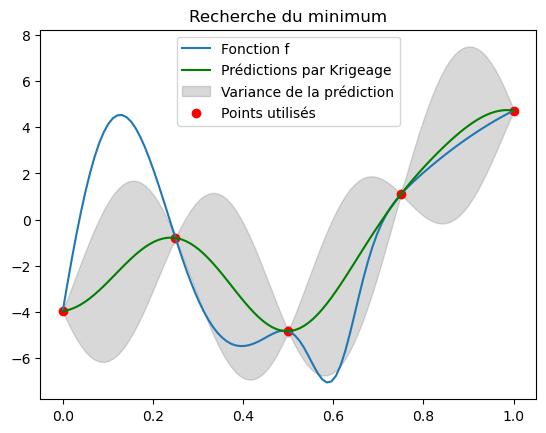

In [ ]:
# Définition du plan d'expérience
pXp = np.linspace(0,1,5)
# Valeurs de la fonction f sur le plan
Z = f(pXp).ravel()
# Points d'interpolation
x = np.linspace(0,1,100)
# Coefficient de régularisation
alpha = 1e-3

# Ajustement du modèle de Krigeage sur les données
y_hat, s_hat = fit_gp(pXp.reshape(-1,1),Z,x.reshape(-1,1),kernel_f,alpha,restart_optimizer=10)
# Affichage de l'ajustement
display_gp(pXp,Z,x,y_hat,s_hat)

## Recherche du minimum

### Critères de maximisation

In [ ]:
def PI(y_hat,z_min,s_hat):
    """
    Défintion de la probabilité d'amélioration (Probability of Improvement).

    Entrées :
        - y_hat : Array - Prédictions faites par Krigeage
        - z_min : Float - Valeur minimale de Z (valeur minimale de f sur le plan d'expérience)
        - s_hat : Array - Variance des prédictions

    Sortie :
        - phi : Float - Valeur de la probabilité d'amélioration
    """

    phi = norm.cdf( (z_min - y_hat) / s_hat )

    return phi

In [ ]:
def EI(y_hat,z_min,s_hat):
    """
    Défintion de l'amélioration espérée (Expected Improvement).

    Entrées :
        - y_hat : Array - Prédictions faites par Krigeage
        - z_min : Float - Valeur minimale de Z (valeur minimale de f sur le plan d'expérience)
        - s_hat : Array - Variance des prédictions

    Sortie :
        - phi : Float - Valeur de l'amélioration espérée
    """

    phi = (z_min - y_hat) * norm.cdf( (z_min - y_hat) / s_hat ) + s_hat * norm.cdf( (z_min - y_hat) / s_hat )

    return phi

### Algorithme EGO

In [ ]:
def EGO(x,x_init,f,criterion,kernel_f,alpha,restart_optimizer,eps,nb_max):
    """
    Implémentation de l'algorithme EGO (Efficient Global Optimization).

    Entrées :
        - x         : Array    - Points d'interpolation
        - x_init    : Array    - Plan d'expérience initial
        - f         : Function - Fonction à interpoler
        - criterion : Function - Critère choisi pour la recherche de nouveax points
        - kernel_f  : Kernel   - Noyau de covariance de f
        - alpha     : Float    - Paramètre de régularisation diagonale
        - restart_optimizer : Integer - Nombre d'appel de la fonction
        - eps       : Float    - Marge d'erreur pour la convergence

    Sorties :
        - p     : Array   - Vecteur des plans d'expérience
        - z     : Array   - Vecteur des valeurs de f sur ces plans
        - y     : Array   - Vecteur des prédictions
        - s     : Array   - Vecteur des variances des prédictions
        - x_min : Float   - Valeur de x où l'optimum approché est trouvé
        - y_min : Float   - Valeur minimale approchée
        - niter : Integer - Nombre d'itérations

    """

    # Récupération du plan d'expérience initial & remise en forme
    x = x.reshape(-1,1)
    pXp = x_init.reshape(-1,1)

    # Création du vecteur Z (valeurs de la fonction f sur le plan)
    Z = f(x_init).ravel()
    # Valeur minimale vraie de la fonction (utilisée pour la convergence)
    true_min = np.min(f(x))

    # 1ere itération de l'algortihme
    y_hat, s_hat = fit_gp(pXp,Z,x,kernel_f,alpha,restart_optimizer)

    # Initialisation des sorties de l'algorithme
    p = [pXp]
    z = [Z]
    y = [y_hat]
    s = [s_hat]

    # Valeur mimale estimée à l'itération n°1
    y_min = np.min(y_hat)
    x_min = x[np.where(y_hat == y_min)[0][0]]

    # Nombre d'itérations
    niter = 1

    # Tant que le minimum estimé n'est pas assez proche du minimum global
    while np.abs(y_min - true_min) > eps:

        # Indices d'évaluation du critère
        ind_crit = np.where(s_hat !=0)

        # Calcul du critère (EI ou PI)
        crit = criterion(y_hat[ind_crit],min(Z),s_hat[ind_crit])

        # Recherche du point qui maximise le critère
        new_x = x[np.where(crit == max(crit))[0][0]].reshape(-1,1)
        new_z = f(new_x).ravel()

        # Ajout du nouveau point au plan d'expérience
        pXp = np.append(pXp,new_x).reshape(-1,1)
        Z = np.append(Z,new_z).ravel()

        # On réalise les prédictions avec ce nouveau plan d'expérience
        y_hat, s_hat = fit_gp(pXp,Z,x,kernel_f,alpha,restart_optimizer)

        # On garde en mémoire le plan, les valeurs de f, les prédictions et leur variance
        p.append(pXp)
        z.append(Z)
        y.append(y_hat)
        s.append(s_hat)

        # Mise à jour du minimum approché
        y_min = np.min(y[-1])
        x_min = x[np.where(y[-1] == y_min)[0][0]]
        # Incrémentation du nombre d'itérations
        niter += 1

        if niter > nb_max:
            return p, z, y, s, x_min, y_min, niter

    return p, z, y, s, x_min, y_min, niter

In [ ]:
def display_ego(x,historic):
    """
    Affiche de manière dynamique la variation du plan d'expérience dans la recherche du minimum.

    Entrée :
        - x        : Array - Points d'interpolation
        - historic : Array - Vecteur de sortie de la fonction précédente
    """
    # Récupération des données contenues dans l'historique
    pXp = historic[0]
    Z = historic[1]
    y_hat = historic[2]
    s = historic[3]
    x_min = historic[4]
    y_min = historic[5]
    niter = historic[6]

    # Pour chaque itération de l'algorithme
    for k in range(len(pXp)):

        # On supprime le plot précédent
        clear_output(wait=True)

        # Nombre de points dans le plan d'expérience
        nb_pt = len(pXp[k])

        # Affichage de la fonction exacte
        plt.plot(x, f(x), label="Fonction f")

        # Affichage des prédictions à l'itération donnée
        plt.plot(x, y_hat[k], color="green", label="Prédictions par Krigeage")

        # Ajout des bandes de confiance
        plt.fill_between(x,
                         [y_hat[k][i] - 2 * s[k][i] for i in range(len(s[k]))],
                         [y_hat[k][i] + 2 * s[k][i] for i in range(len(s[k]))],
                         color="grey", alpha=0.3,label="Variance de la prédiction")  # alpha pour la transparence

        # Ajout du plan d'expérience de l'itération concernée
        plt.scatter(pXp[k], Z[k], color="red", label="Points utilisés")

        # Ajout du titre et de la légende
        plt.title(f"Recherche du minimum")

        # Si on est à la dernière itération, on affiche le minimum approché
        if k == len(pXp)-1:
            plt.scatter(x_min,y_min,color="black",label="Minimum obtenu")

        plt.legend()
        plt.show()
        # Pour la dynamique, on attend 0.01s avant de passer à l'affichage de l'itération suivante
        time.sleep(0.01)

    # Affichages finaux
    print(f"Minimum obtenu : ({x_min}, {y_min}).")
    print(f"Nombre d'itérations : {niter}.")
    print(f"Ecart absolu avec le minimum global : {np.round(abs(y_min-np.min(f(x))),3)}.")
    print(f"Ecart relatif avec le minimum global : {100*np.round(abs(y_min-np.min(f(x)))/abs(np.min(f(x))),3)}%.")

In [ ]:
def display_ego_animation(x, historic, filename, fps=10):
    """
    Génère et sauvegarde une animation de la variation du plan d'expérience.

    Entrée :
        - x        : Array - Points d'interpolation
        - historic : Array - Vecteur de sortie de la fonction précédente
        - filename : str   - Nom du fichier de sortie (GIF ou MP4)
        - fps      : int   - Images par seconde pour la vidéo/GIF
    """
    # Récupération des données contenues dans l'historique
    pXp = historic[0]
    Z = historic[1]
    y_hat = historic[2]
    s = historic[3]
    x_min = historic[4]
    y_min = historic[5]
    niter = historic[6]

    # Initialisation de la figure
    fig, ax = plt.subplots()

    def update(k):
        """Fonction d'update pour l'animation."""
        ax.clear()

        # Affichage de la fonction exacte
        ax.plot(x, f(x), label="Fonction f")

        # Affichage des prédictions à l'itération donnée
        ax.plot(x, y_hat[k], color="green", label="Prédictions par Krigeage")

        # Ajout des bandes de confiance
        ax.fill_between(x,
                        [y_hat[k][i] - 2 * s[k][i] for i in range(len(s[k]))],
                        [y_hat[k][i] + 2 * s[k][i] for i in range(len(s[k]))],
                        color="grey", alpha=0.3, label="Variance de la prédiction")  # alpha pour la transparence

        # Ajout du plan d'expérience de l'itération concernée
        ax.scatter(pXp[k], Z[k], color="red", label="Points utilisés")

        # Ajout du titre et de la légende
        ax.set_title(f"Recherche du minimum - Itération {k+1}/{len(pXp)}")

        # Si on est à la dernière itération, on affiche le minimum approché
        if k == len(pXp)-1:
            ax.scatter(x_min, y_min, color="black", label="Minimum obtenu")

        ax.legend()

    # Création de l'animation
    ani = FuncAnimation(fig, update, frames=len(pXp), interval=1000/fps)

    # Sauvegarde de l'animation
    if filename.endswith(".gif"):
        ani.save(filename, writer="pillow", fps=fps)
    elif filename.endswith(".mp4"):
        writer = FFMpegWriter(fps=fps, metadata={"title": "EGO Animation"})
        ani.save(filename, writer=writer)
    else:
        raise ValueError("Le fichier de sortie doit être un .gif ou un .mp4")

    plt.close(fig)  # Fermer la figure après l'enregistrement
    print(f"Animation sauvegardée sous '{filename}'.")

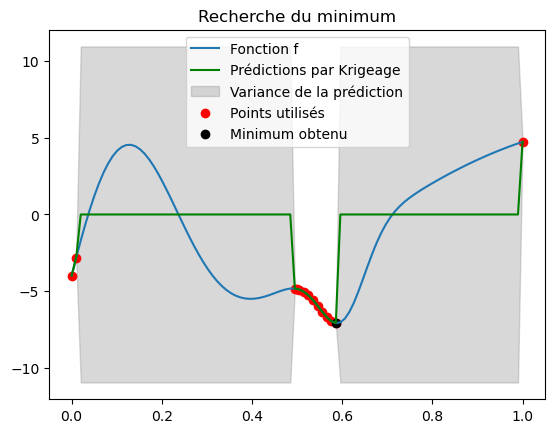

Minimum obtenu : ([0.58585859], -7.065208016365179).
Nombre d'itérations : 12.
Ecart absolu avec le minimum global : 0.0.
Ecart relatif avec le minimum global : 0.0%.


In [ ]:
# Initialisation du plan d'expérience
x_init = np.array([0,0.5,1])
# Points d'interpolation
x = np.linspace(0,1,100)
# Critère, marge d'erreur et paramètre de régularisation
criterion = PI
eps = 0.1
alpha = 1e-3
nb_max = 20

# Recherche du minimum
historic_PI = EGO(x,x_init,f,criterion,kernel_f,alpha,restart_optimizer=10,eps=eps,nb_max=nb_max)
# Affichage dynamique de cette recherche
display_ego(x,historic_PI)

In [ ]:
# Exemple d'appel
display_ego_animation(x, historic_PI, filename="ego_PI.gif", fps=2)

Animation sauvegardée sous 'ego_PI.gif'.


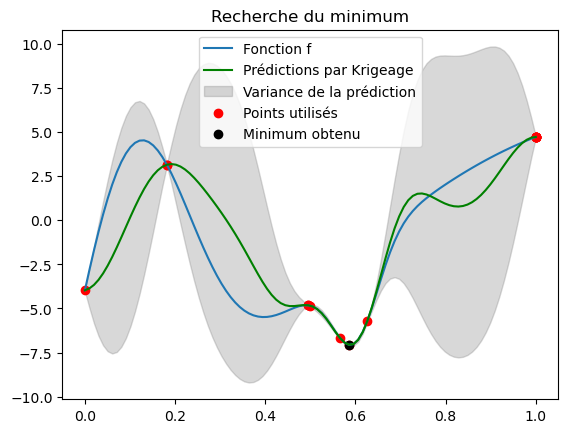

Minimum obtenu : ([0.58585859], -7.060235025274601).
Nombre d'itérations : 14.
Ecart absolu avec le minimum global : 0.005.
Ecart relatif avec le minimum global : 0.1%.


In [ ]:
# Plan d'expérience initial
x_init = np.array([0,0.5,1])
# Points d'interpolation
x = np.linspace(0,1,100)
# Critère choisi, marge d'erreur et paramètre de régularisation diagonale
criterion = EI
eps = 0.1
alpha = 1e-3
nb_max = 20

# Recherche du minimum
historic_EI = EGO(x,x_init,f,criterion,kernel_f,alpha,restart_optimizer=10,eps=eps,nb_max=nb_max)
# Affichage dynamique de la recherche
display_ego(x,historic_EI)

In [ ]:
# Exemple d'appel
display_ego_animation(x, historic_EI, filename="ego_EI.gif", fps=2)

Animation sauvegardée sous 'ego_EI.gif'.


## Optimisation sous contraintes

In [ ]:
def g(x):
    #y = - np.sin(x*25+50)/2*np.cos(5*x) + np.tan(1/(x+1)) - 0.8
    #y = x - 1/2
    y = np.cos(2*np.pi*x + np.pi/2)
    return y

kernel_g = ConstantKernel(constant_value=25.0) * RBF(length_scale=0.5, length_scale_bounds=(1e-6, 1e5))

Text(0.5, 1.0, 'Affichage de la fonction g sur [0,1]')

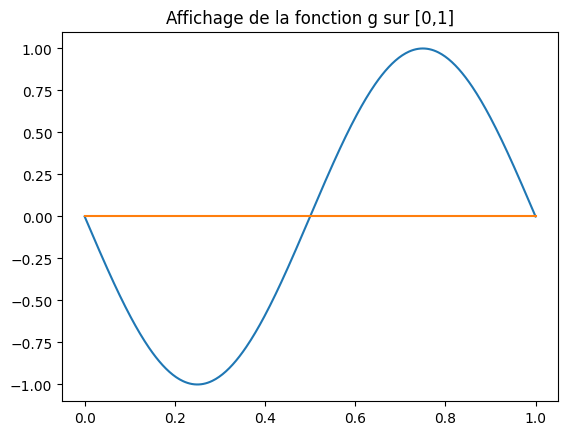

In [ ]:
# Grille d'abscisses
x = np.linspace(0,1,400)

# Affichage graphique
plt.plot(x,g(x),label="Fonction g")
plt.plot(x,np.zeros(len(x)))
plt.title("Affichage de la fonction g sur [0,1]")

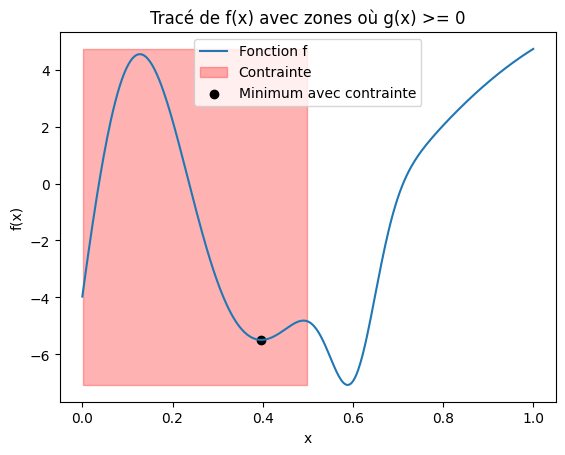

In [ ]:
# Grille d'abscisses
x = np.linspace(0,1,400)

# Affichage graphique
func = f(x)
gunc = g(x)
plt.plot(x,f(x),label="Fonction f")

# Mise en évidence des zones où la contrainte et valide
plt.fill_between(x, np.min(func), np.max(func), where=(gunc <= 0), color='red', alpha=0.3, label="Contrainte")

func_ok = func*(gunc <= 0)
true_min = np.min(func_ok)

plt.scatter(x[np.where(func_ok==true_min)[0][0]],true_min,color="black",label="Minimum avec contrainte")

# Ajouter des labels, légende et grille
plt.xlabel("x")
plt.ylabel("f(x)")
plt.legend()
plt.title("Tracé de f(x) avec zones où g(x) >= 0")
plt.show()


### Critères de maximisation

In [ ]:
def EIxPF(y_hat,z_min,s_hat,g_hat,s_g_hat,threshold=None):
    """
    Définition du critère utilisant la probabilité de réalisabilité de la contrainte.

    Entrées :
        - y_hat     : Array - Prédictions de la fonction f
        - z_min     : Float - Valeur minimale de f sur le plan d'expérience
        - s_hat     : Array - Variance des prédictions de f réalisées
        - g_hat     : Array - Prédictions de la fonction contrainte g
        - s_g_hat   : Array - Variance des prédictions de g réalisées
        - threshold : Float - Paramètre non utilisé (ajouté pour avoir les mêmes paramètres que les autres critères)

    Sortie :
        - criterion : Float - Valeur du critère considéré
    """
    Ei = EI(y_hat,z_min,s_hat)

    Pf = norm.cdf( - g_hat / s_g_hat )

    criterion = Ei*Pf

    return criterion

In [ ]:
def EV(y_hat,z_min,s_hat,g_hat,s_g_hat,threshold):
    """
    Définition du critère utilisant la violation espérée de la contrainte.

    Entrées :
        - y_hat     : Array - Prédictions de la fonction f
        - z_min     : Float - Valeur minimale de f sur le plan d'expérience
        - s_hat     : Array - Variance des prédictions de f réalisées
        - g_hat     : Array - Prédictions de la fonction contrainte g
        - s_g_hat   : Array - Variance des prédictions de g réalisées
        - threshold : Float - Seuil considéré dans la gestion de la violation

    Sortie :
        - criterion : Float - Valeur du critère considéré
    """
    Ei = EI(y_hat,z_min,s_hat)

    phi = - g_hat * norm.cdf( - g_hat / s_g_hat ) + s_g_hat * norm.cdf( - g_hat / s_g_hat )

    criterion = Ei*(phi >= threshold)

    return criterion

In [ ]:
def Constrained_EI(y_hat,z_min,s_hat,g_hat,s_g_hat=None,threshold=None):
    """
    Définition du critère utilisant l'amélioration espérée contrainte.

    Entrées :
        - y_hat     : Array - Prédictions de la fonction f
        - z_min     : Float - Valeur minimale de f sur le plan d'expérience
        - s_hat     : Array - Variance des prédictions de f réalisées
        - g_hat     : Array - Prédictions de la fonction contrainte g
        - s_g_hat   : Array - Paramètre non utilisé (ajouté pour avoir les mêmes paramètres que les autres critères)
        - threshold : Float - Paramètre non utilisé (ajouté pour avoir les mêmes paramètres que les autres critères)

    Sortie :
        - criterion : Float - Valeur du critère considéré
    """
    Ei = EI(y_hat,z_min,s_hat)

    criterion = Ei*(g_hat <= 0)

    return criterion

### Algorithme EGO

In [ ]:
def EGO_constrained(x,x_init,f,g,criterion,kernel_f,kernel_g,alpha,restart_optimizer,eps,nb_max,threshold=None):
    """
    Implémentation de l'algorithme EGO (Efficient Global Optimization) pour la minimisation sous contraintes.

    Entrées :
        - x         : Array    - Points d'interpolation
        - x_init    : Array    - Plan d'expérience initial
        - f         : Function - Fonction à interpoler
        - g         : Function - Fonction contrainte
        - criterion : Function - Critère choisi pour la recherche de nouveax points
        - kernel_f  : Kernel   - Noyau de covariance de f
        - kernel_g  : Kernel   - Noyau de covariance de g
        - alpha     : Float    - Paramètre de régularisation diagonale
        - restart_optimizer : Integer - Nombre d'appels àla fonction
        - eps       : Float    - Marge d'erreur pour la convergence
        - threshold : Float    - Seuil utilisé dans le cas où le critère choisi est la violation espérée

    Sorties :
        - p     : Array   - Vecteur des plans d'expérience

        - z_f   : Array   - Vecteur des valeurs de f sur ces plans
        - y_f   : Array   - Vecteur des prédictions de f
        - s_f   : Array   - Vecteur des variances des prédictions pour f

        - z_g   : Array   - Vecteur des valeurs de g sur ces plans
        - y_g   : Array   - Vecteur des prédictions pour la contrainte g
        - s_g   : Array   - Vecteur des variances des prédictions pour g

        - x_min : Float   - Valeur de x où l'optimum approché est trouvé
        - y_min : Float   - Valeur minimale approchée
        - niter : Integer - Nombre d'itérations

    """

    # Récupération du plan d'expérience initial
    x = x.reshape(-1,1)
    pXp = x_init.reshape(-1,1)

    # Création du vecteur Z (valeurs de la fonction f sur le plan)
    Z_f = f(x_init).ravel()
    # Calcul des valeurs de g sur ce plan
    Z_g = g(x_init).ravel()

    # 1ere itération de l'algorithme
    ## Approximation de la fonction f
    y_f_hat, s_f_hat = fit_gp(pXp,Z_f,x,kernel_f,alpha,restart_optimizer)
    ## Approximation de la contrainte g
    y_g_hat, s_g_hat = fit_gp(pXp,Z_g,x,kernel_g,alpha,restart_optimizer)

    # Initialisation des sorties de l'algorithme
    p = [pXp]
    z_f = [Z_f]
    y_f = [y_f_hat]
    s_f = [s_f_hat]
    z_g = [Z_g]
    y_g = [y_g_hat]
    s_g = [s_g_hat]

    # Valeur minimale vraie de la fonction (pour la convergence), en vérifiant la contrainte
    true_min = np.min(f(x)*(g(x) <= 0))

    # Valeur minimale estimée à l'itération n°1
    y_min = np.min(y_f_hat*(y_g_hat <= 0))

    # Nombre d'itérations
    niter = 1

    # Tant que le minimum estimé n'est pas assez proche du minimum global
    while np.abs(y_min - true_min) > eps:

        # Indices d'évaluation du critère
        ind_crit = np.where(s_f_hat !=0)

        # Calcul du critère
        crit = criterion(y_f_hat[ind_crit],min(Z_f),s_f_hat[ind_crit],y_g_hat[ind_crit],s_g_hat[ind_crit],threshold)

        # Recherche du point qui maximise le critère
        new_x = x[np.where(crit == max(crit))[0][0]].reshape(-1,1)
        new_z_f = f(new_x).ravel()
        new_z_g = g(new_x).ravel()

        # Ajout du nouveau point au plan d'expérience
        pXp = np.append(pXp,new_x).reshape(-1,1)
        Z_f = np.append(Z_f,new_z_f).ravel()
        Z_g = np.append(Z_g,new_z_g).ravel()

        # Réalisation des prédictions avec ce nouveau plan d'expérience
        y_f_hat, s_f_hat = fit_gp(pXp,Z_f,x,kernel_f,alpha,restart_optimizer)
        y_g_hat, s_g_hat = fit_gp(pXp,Z_g,x,kernel_g,alpha,restart_optimizer)

        # On garde en mémoire l'évolution du krigeage
        p.append(pXp)
        z_f.append(Z_f)
        y_f.append(y_f_hat)
        s_f.append(s_f_hat)
        z_g.append(Z_g)
        y_g.append(y_g_hat)
        s_g.append(s_g_hat)

        # Mise à jour de la valeur minimale trouvée
        y_min = np.min(y_f[-1]*(y_g[-1] <= 0))
        x_min = x[np.where(y_f[-1]*(y_g[-1] <= 0) == y_min)[0][0]]
        # Incrémentation du nombre d'itérations
        niter += 1

        if niter >= nb_max:
            return p, z_f, y_f, s_f, z_g, y_g, s_g, x_min, y_min, niter

    return p, z_f, y_f, s_f, z_g, y_g, s_g, x_min, y_min, niter

In [ ]:
def display_ego_constrained(x,historic):
    """
    Affiche de manière dynamique la variation du plan d'expérience dans la recherche du minimum.

    Entrée :
        - x        : Array - Points d'interpolation
        - historic : Array - Vecteur de sortie de la fonction précédente
    """
    # Récupération des données contenues dans l'historique
    pXp = historic[0]

    Z_f = historic[1]
    y_f_hat = historic[2]
    s_f = historic[3]

    Z_g = historic[4]
    y_g_hat = historic[5]
    s_g = historic[6]

    x_min = historic[7]
    y_min = historic[8]
    niter = historic[9]

    # Animation de la recherche
    for k in range(len(pXp)):
       # On supprime le plot précédent
        clear_output(wait=True)

        # Nombre de points dans le plan d'expérience
        nb_pt = len(pXp[k])

        # Axe 0 : Fonction f et contraintes
        plt.plot(x, f(x), label="Fonction f", color="blue")

        plt.fill_between(x, np.min(f(x)), np.max(f(x)), where=(y_g_hat[k] <= 0), color='red', alpha=0.3, label="Contrainte")

        plt.plot(x, y_f_hat[k], color="green", label="Prédictions par Krigeage")

        plt.fill_between(x,
                            y_f_hat[k] - 2 * s_f[k],
                            y_f_hat[k] + 2 * s_f[k],
                            color="grey", alpha=0.3, label="Variance de la prédiction")

        plt.scatter(pXp[k], Z_f[k], color="red", label="Points utilisés")

        # Si on est à la dernière itération, on affiche le minimum approché
        if k == len(pXp)-1:
            plt.scatter(x_min,y_min,color="black",label="Minimum obtenu")


        plt.title(f"Recherche du minimum - itération {k+1}")

        plt.legend()
        plt.show()
        # Mise à jour de la figure
        plt.pause(0.5)  # Pause pour la mise à jour dynamique

    true_min = np.min(f(x)*(g(x) <= 0))
    # Affichages finaux
    print(f"Minimum obtenu : ({x_min}, {y_min}).")
    print(f"Nombre d'itérations : {niter}.")
    print(f"Ecart absolu avec le minimum global : {np.round(abs(y_min-true_min),3)}.")
    print(f"Ecart relatif avec le minimum global : {100*np.round(abs(y_min-true_min)/abs(true_min),3)}%.")

In [ ]:
def display_ego_constrained_animation(x, historic, filename, fps=10):
    """
    Génère et sauvegarde une animation de la recherche du minimum avec contraintes.

    Entrée :
        - x        : Array - Points d'interpolation
        - historic : Array - Vecteur de sortie de la fonction précédente
        - filename : str   - Nom du fichier de sortie (GIF ou MP4)
        - fps      : int   - Images par seconde pour la vidéo/GIF
    """
    # Récupération des données contenues dans l'historique
    pXp = historic[0]
    Z_f = historic[1]
    y_f_hat = historic[2]
    s_f = historic[3]
    Z_g = historic[4]
    y_g_hat = historic[5]
    s_g = historic[6]
    x_min = historic[7]
    y_min = historic[8]
    niter = historic[9]

    # Initialisation de la figure
    fig, ax = plt.subplots()

    def update(k):
        """Fonction d'update pour l'animation."""
        ax.clear()

        # Affichage de la fonction f
        ax.plot(x, f(x), label="Fonction f", color="blue")

        # Visualisation de la contrainte
        ax.fill_between(
            x, np.min(f(x)), np.max(f(x)),
            where=(y_g_hat[k] <= 0),
            color='red', alpha=0.3, label="Contrainte")

        # Affichage des prédictions pour f
        ax.plot(x, y_f_hat[k], color="green", label="Prédictions par Krigeage")
        ax.fill_between(
            x,
            y_f_hat[k] - 2 * s_f[k],
            y_f_hat[k] + 2 * s_f[k],
            color="grey", alpha=0.3, label="Variance de la prédiction")

        # Points utilisés
        ax.scatter(pXp[k], Z_f[k], color="red", label="Points utilisés")

        # Minimum approché à la dernière itération
        if k == len(pXp) - 1:
            ax.scatter(x_min, y_min, color="black", label="Minimum obtenu")

        # Titre et légende
        ax.set_title(f"Recherche du minimum (itération {k+1}/{len(pXp)})")
        ax.legend()

    # Création de l'animation
    ani = FuncAnimation(fig, update, frames=len(pXp), interval=1000/fps)

    # Sauvegarde de l'animation
    if filename.endswith(".gif"):
        ani.save(filename, writer="pillow", fps=fps)
    elif filename.endswith(".mp4"):
        writer = FFMpegWriter(fps=fps, metadata={"title": "EGO Constrained Animation"})
        ani.save(filename, writer=writer)
    else:
        raise ValueError("Le fichier de sortie doit être un .gif ou un .mp4")

    plt.close(fig)  # Fermer la figure après l'enregistrement
    print(f"Animation sauvegardée sous '{filename}'.")

# Exemple d'appel
# display_ego_constrained_animation(x, historic, filename="ego_constrained_animation.mp4", fps=10)


In [ ]:
def display_g(x,historic):
    """
    Affiche de manière dynamique la variation du plan d'expérience dans l'heuristique présentée précédemment.

    Entrée :
        - historic : Array - Vecteur de sortie de la fonction précédente
    """
    p = historic[0]
    g_hat = historic[5]
    s_g_hat = historic[6]

    # Pour chaque itération de l'algorithme
    for k in range(len(p)):
        # On supprime le plot précédent
        clear_output(wait=True)
        # Récupération des données de l'historique
        nb_pt = len(p[k])
        # Affichage de la fonction exacte
        plt.plot(x, g(x), label="Fonction g")
        # Affichage des prédictions à l'itération donnée
        plt.plot(x, g_hat[k], color="green", label="Prédictions par Krigeage")

        # Ajout des bandes de confiance
        plt.fill_between(x,
                         [g_hat[k][i] - 2 * s_g_hat[k][i] for i in range(len(s_g_hat[k]))],
                         [g_hat[k][i] + 2 * s_g_hat[k][i] for i in range(len(s_g_hat[k]))],
                         color="grey", alpha=0.3,label="Variance de la prédiction")  # alpha pour la transparence

        # Ajout du plan d'expérience de l'itération concernée
        plt.scatter(p[k], g(p[k]), color="red", label="Points utilisés")

        # Ajout du titre et de la légende
        plt.title(f"Approximation de la fonction g - Itération {k+1}/{len(p)}")
        plt.legend()
        plt.show()
        # Pour la dynamique, on attend 0.3s avant de passer à l'affichage de l'itération suivante
        time.sleep(0.3)

In [ ]:
def display_g_animation(x, historic, filename="g_animation.gif", fps=10):
    """
    Génère et sauvegarde une animation de l'approximation de la fonction g.

    Entrée :
        - x        : Array - Points d'interpolation
        - historic : Array - Historique des résultats
        - filename : str   - Nom du fichier de sortie (GIF ou MP4)
        - fps      : int   - Images par seconde pour la vidéo/GIF
    """
    p = historic[0]
    g_hat = historic[5]
    s_g_hat = historic[6]

    # Initialisation de la figure
    fig, ax = plt.subplots()

    def update(k):
        """Fonction d'update pour l'animation."""
        ax.clear()

        # Affichage de la fonction exacte
        ax.plot(x, g(x), label="Fonction g", color="blue")

        # Affichage des prédictions pour g
        ax.plot(x, g_hat[k], color="green", label="Prédictions par Krigeage")

        # Ajout des bandes de confiance
        ax.fill_between(
            x,
            [g_hat[k][i] - 2 * s_g_hat[k][i] for i in range(len(s_g_hat[k]))],
            [g_hat[k][i] + 2 * s_g_hat[k][i] for i in range(len(s_g_hat[k]))],
            color="grey", alpha=0.3, label="Variance de la prédiction")

        # Points utilisés pour la prédiction
        ax.scatter(p[k], g(p[k]), color="red", label="Points utilisés")

        # Titre et légende
        ax.set_title(f"Approximation de la fonction g - Itération {k+1}/{len(p)}")
        ax.legend()

    # Création de l'animation
    ani = FuncAnimation(fig, update, frames=len(p), interval=1000/fps)

    # Sauvegarde de l'animation
    if filename.endswith(".gif"):
        ani.save(filename, writer="pillow", fps=fps)
    elif filename.endswith(".mp4"):
        writer = FFMpegWriter(fps=fps, metadata={"title": "g Animation"})
        ani.save(filename, writer=writer)
    else:
        raise ValueError("Le fichier de sortie doit être un .gif ou un .mp4")

    plt.close(fig)  # Fermer la figure après l'enregistrement
    print(f"Animation sauvegardée sous '{filename}'.")

# Exemple d'appel
# display_g_animation(x, historic, filename="g_animation.mp4", fps=10)


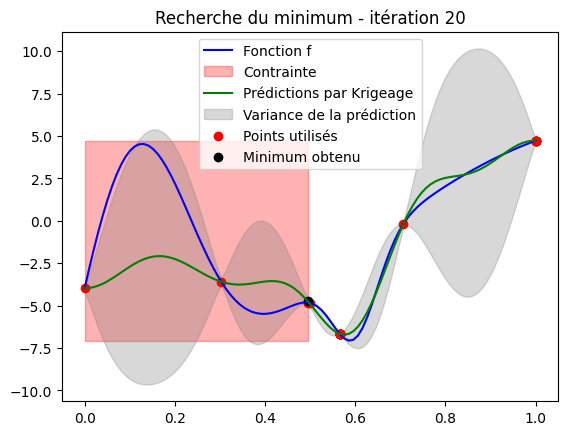

Minimum obtenu : ([0.49494949], -4.754769496451937).
Nombre d'itérations : 20.
Ecart absolu avec le minimum global : 0.733.
Ecart relatif avec le minimum global : 13.4%.


In [ ]:
# Plan d'expérience initial
x_init = np.array([0,0.5,1])
# Points d'interpolation
x = np.linspace(0,1,100)
# Marge d'erreur, paramètre de régularisation et critère de recherche
eps = 0.1
alpha = 1e-2
criterion = EIxPF
nb_max=20

historic_EIxPF = EGO_constrained(x,x_init,f,g,criterion,kernel_f,kernel_g,alpha,restart_optimizer=20,eps=eps,nb_max=nb_max)
display_ego_constrained(x,historic_EIxPF)

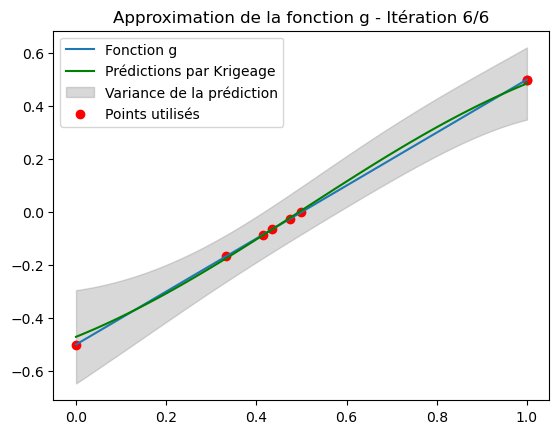

In [ ]:
display_g(x,historic_EIxPF)

In [ ]:
# Exemple d'appel
display_ego_constrained_animation(x, historic_EIxPF, filename="ego_EIxPF.gif", fps=2)

Animation sauvegardée sous 'ego_EIxPF.gif'.


In [ ]:
display_g_animation(x,historic_EIxPF,filename="g_EIxPF.gif",fps=2)

Animation sauvegardée sous 'g_EIxPF.gif'.


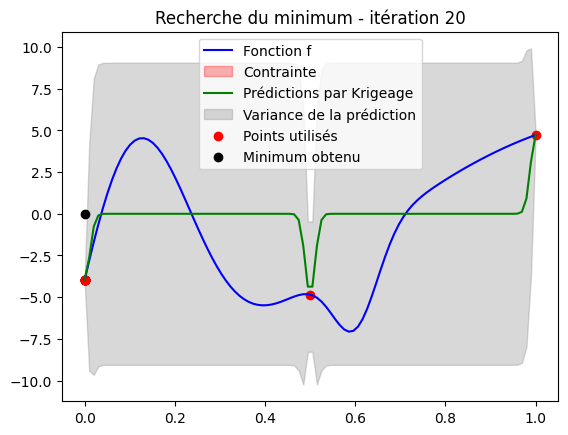

Minimum obtenu : ([0.], 0.0).
Nombre d'itérations : 20.
Ecart absolu avec le minimum global : 5.488.
Ecart relatif avec le minimum global : 100.0%.


In [ ]:
# Plan d'expérience initial
x_init = np.array([0,0.5,1])
# Points d'interpolation
x = np.linspace(0,1,100)
# Marge d'erreur, paramètre de régularisation et critère de recherche
eps = 0.1
alpha = 1e-2
criterion = Constrained_EI
nb_max=20

historic_CEI = EGO_constrained(x,x_init,f,g,criterion,kernel_f,kernel_g,alpha,restart_optimizer=20,eps=eps,nb_max=nb_max)
display_ego_constrained(x,historic_CEI)

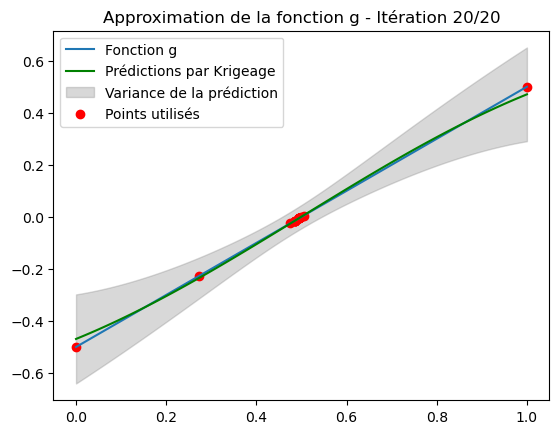

In [ ]:
display_g(x,historic_CEI)

In [ ]:
# Exemple d'appel
display_ego_constrained_animation(x, historic_CEI, filename="ego_CEI.gif", fps=2)

Animation sauvegardée sous 'ego_CEI.gif'.


In [ ]:
display_g_animation(x,historic_CEI,filename="g_CEI.gif",fps=2)

Animation sauvegardée sous 'g_CEI.gif'.


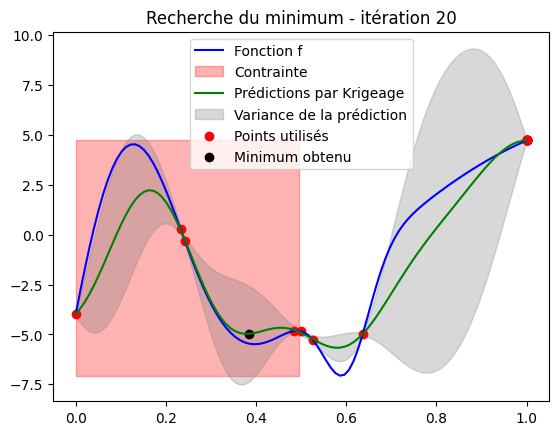

Minimum obtenu : ([0.38383838], -4.967360424623237).
Nombre d'itérations : 20.
Ecart absolu avec le minimum global : 0.52.
Ecart relatif avec le minimum global : 9.5%.


In [ ]:
# Plan d'expérience initial
x_init = np.array([0,0.5,1])
# Points d'interpolation
x = np.linspace(0,1,100)
# Marge d'erreur, paramètre de régularisation et critère de recherche
eps = 0.1
alpha = 1e-2
criterion = EV
nb_max=20

historic_EV = EGO_constrained(x,x_init,f,g,criterion,kernel_f,kernel_g,alpha,restart_optimizer=20,eps=eps,nb_max=nb_max,threshold=1e-3)
display_ego_constrained(x,historic_EV)

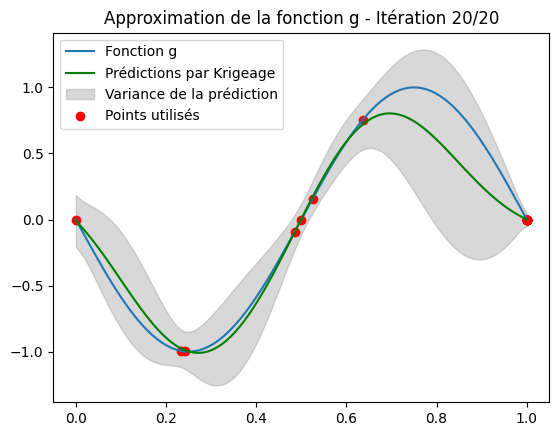

In [ ]:
display_g(x,historic_EV)

In [ ]:
# Exemple d'appel
display_ego_constrained_animation(x, historic_EV, filename="ego_EV.gif", fps=2)

Animation sauvegardée sous 'ego_EV.gif'.


In [ ]:
display_g_animation(x,historic_EV,filename="g_EV.gif",fps=2)

Animation sauvegardée sous 'g_EV.gif'.


### Maximisation d'un bi-objectif

In [ ]:
def bi_objective(y_hat,z_min,s_hat,g_hat,s_g_hat):
    """
    Définition du critère utilisant la probabilité de réalisabilité de la contrainte.

    Entrées :
        - y_hat     : Array - Prédictions de la fonction f
        - z_min     : Float - Valeur minimale de f sur le plan d'expérience
        - s_hat     : Array - Variance des prédictions de f réalisées
        - g_hat     : Array - Prédictions de la fonction contrainte g
        - s_g_hat   : Array - Variance des prédictions de g réalisées

    Sortie :
        - criterion : Float - Valeur du critère considéré
    """
    Ei = EI(y_hat,z_min,s_hat)

    Pf = norm.cdf( - g_hat / s_g_hat )

    return Ei,Pf

In [ ]:
def EGO_bi_objective(x,x_init,f,g,kernel_f,kernel_g,alpha,restart_optimizer,eps,nb_max):
    """
    Implémentation de l'algorithme EGO (Efficient Global Optimization) pour la minimisation sous contraintes.

    Entrées :
        - x         : Array    - Points d'interpolation
        - x_init    : Array    - Plan d'expérience initial
        - f         : Function - Fonction à interpoler
        - g         : Function - Fonction contrainte
        - kernel_f  : Kernel   - Noyau de covariance de f
        - kernel_g  : Kernel   - Noyau de covariance de g
        - alpha     : Float    - Paramètre de régularisation diagonale
        - restart_optimizer : Integer - Nombre d'appels àla fonction
        - eps       : Float    - Marge d'erreur pour la convergence
        - threshold : Float    - Seuil utilisé dans le cas où le critère choisi est la violation espérée

    Sorties :
        - p     : Array   - Vecteur des plans d'expérience

        - z_f   : Array   - Vecteur des valeurs de f sur ces plans
        - y_f   : Array   - Vecteur des prédictions de f
        - s_f   : Array   - Vecteur des variances des prédictions pour f

        - z_g   : Array   - Vecteur des valeurs de g sur ces plans
        - y_g   : Array   - Vecteur des prédictions pour la contrainte g
        - s_g   : Array   - Vecteur des variances des prédictions pour g

        - x_min : Float   - Valeur de x où l'optimum approché est trouvé
        - y_min : Float   - Valeur minimale approchée
        - niter : Integer - Nombre d'itérations

    """

    # Récupération du plan d'expérience initial
    x = x.reshape(-1,1)
    pXp = x_init.reshape(-1,1)

    # Création du vecteur Z (valeurs de la fonction f sur le plan)
    Z_f = f(x_init).ravel()
    # Calcul des valeurs de g sur ce plan
    Z_g = g(x_init).ravel()

    # 1ere itération de l'algorithme
    ## Approximation de la fonction f
    y_f_hat, s_f_hat = fit_gp(pXp,Z_f,x,kernel_f,alpha,restart_optimizer)
    ## Approximation de la contrainte g
    y_g_hat, s_g_hat = fit_gp(pXp,Z_g,x,kernel_g,alpha,restart_optimizer)

    # Initialisation des sorties de l'algorithme
    p = [pXp]
    z_f = [Z_f]
    y_f = [y_f_hat]
    s_f = [s_f_hat]
    z_g = [Z_g]
    y_g = [y_g_hat]
    s_g = [s_g_hat]

    # Valeur minimale vraie de la fonction (pour la convergence), en vérifiant la contrainte
    true_min = np.min(f(x)*(g(x) <= 0))

    # Valeur minimale estimée à l'itération n°1
    y_min = np.min(y_f_hat*(y_g_hat <= 0))

    # Nombre d'itérations
    niter = 1

    # Tant que le minimum estimé n'est pas assez proche du minimum global
    while np.abs(y_min - true_min) > eps:

        # Indices d'évaluation du critère
        ind_crit = np.where(s_hat !=0)

        # Calcul du critère
        Ei, Pf = bi_objective(y_f_hat[ind_crit],min(Z),s_f_hat[ind_crit],y_g_hat[ind_crit],s_g_hat[ind_crit])

        # On récupère les indices max des deux critères
        ind_EI = np.where(Ei == max(Ei))[0][0]
        ind_PF = np.where(Pf == max(Pf))[0][0]

        # On calcule pour chacun le produit PFxEI
        z_EI = EIxPF(y_f_hat[ind_EI],min(Z),s_f_hat[ind_EI],y_g_hat[ind_EI],s_g_hat[ind_EI])
        z_PF = EIxPF(y_f_hat[ind_PF],min(Z),s_f_hat[ind_PF],y_g_hat[ind_PF],s_g_hat[ind_PF])

        # On sélectionne le point qui maximise le produit
        if z_EI >= z_PF:
            new_x = x[ind_EI].reshape(-1,1)
        else:
            new_x = x[ind_PF].reshape(-1,1)

        new_z_f = f(new_x).ravel()
        new_z_g = g(new_x).ravel()

        # Ajout du nouveau point au plan d'expérience
        pXp = np.append(pXp,new_x).reshape(-1,1)
        Z_f = np.append(Z_f,new_z_f).ravel()
        Z_g = np.append(Z_g,new_z_g).ravel()

        # Réalisation des prédictions avec ce nouveau plan d'expérience
        y_f_hat, s_f_hat = fit_gp(pXp,Z_f,x,kernel_f,alpha,restart_optimizer)
        y_g_hat, s_g_hat = fit_gp(pXp,Z_g,x,kernel_g,alpha,restart_optimizer)

        # On garde en mémoire l'évolution du krigeage
        p.append(pXp)
        z_f.append(Z_f)
        y_f.append(y_f_hat)
        s_f.append(s_f_hat)
        z_g.append(Z_g)
        y_g.append(y_g_hat)
        s_g.append(s_g_hat)

        # Mise à jour de la valeur minimale trouvée
        y_min = np.min(y_f[-1]*(y_g[-1] <= 0))
        x_min = x[np.where(y_f[-1]*(y_g[-1] <= 0) == y_min)[0][0]]
        # Incrémentation du nombre d'itérations
        niter += 1

        if niter >= nb_max:
            return p, z_f, y_f, s_f, z_g, y_g, s_g, x_min, y_min, niter


    return p, z_f, y_f, s_f, z_g, y_g, s_g, x_min, y_min, niter

In [ ]:
# Plan d'expérience initial
x_init = np.array([0,0.5,1])
# Points d'interpolation
x = np.linspace(0,1,100)
# Marge d'erreur, paramètre de régularisation et critère de recherche
eps = 0.1
alpha = 0.0
nb_max = 20

historic_bi_obj = EGO_bi_objective(x,x_init,f,g,kernel_f,kernel_g,alpha,restart_optimizer=15,eps=eps,nb_max=nb_max)
display_ego_constrained(x,historic_bi_obj)

C:\Users\BLo\anaconda3\lib\site-packages\sklearn\gaussian_process\_gpr.py:629: ConvergenceWarning: lbfgs failed to converge (status=2):
ABNORMAL_TERMINATION_IN_LNSRCH.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)
C:\Users\BLo\anaconda3\lib\site-packages\sklearn\gaussian_process\kernels.py:430: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__constant_value is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
C:\Users\BLo\anaconda3\lib\site-packages\sklearn\gaussian_process\_gpr.py:445: UserWarning: Predicted variances smaller than 0. Setting those variances to 0.
  warnings.warn(
C:\Users\BLo\AppData\Local\Temp\ipykernel_476\3955279970.py:17: RuntimeWarning: divide by zero encountered in divide
  Pf = norm.cdf( - g_hat / s_g_hat )
C:\Users\BLo\

LinAlgError: ("The kernel, 5**2 * RBF(length_scale=0.5), is not returning a positive definite matrix. Try gradually increasing the 'alpha' parameter of your GaussianProcessRegressor estimator.", '6-th leading minor of the array is not positive definite')

In [ ]:
display_g(x,historic_bi_obj)

In [ ]:
# Exemple d'appel
display_ego_constrained_animation(x, historic_bi_obj, filename="ego_bi_obj.gif", fps=2)

In [ ]:
# Exemple d'appel
display_g_animation(x, historic_bi_obj, filename="g_bi_obj.gif", fps=2)

### Maximisation d'un tri-objectif

In [ ]:
def tri_objective(y_hat,z_min,s_hat,g_hat,s_g_hat):
    """
    Définition du critère utilisant la probabilité de réalisabilité de la contrainte.

    Entrées :
        - y_hat     : Array - Prédictions de la fonction f
        - z_min     : Float - Valeur minimale de f sur le plan d'expérience
        - s_hat     : Array - Variance des prédictions de f réalisées
        - g_hat     : Array - Prédictions de la fonction contrainte g
        - s_g_hat   : Array - Variance des prédictions de g réalisées
        - threshold : Float - Paramètre non utilisé (ajouté pour avoir les mêmes paramètres que les autres critères)

    Sortie :
        - criterion : Float - Valeur du critère considéré
    """
    Ei = EI(y_hat,z_min,s_hat)

    Pf = norm.cdf( - g_hat / s_g_hat )

    s = - s_g_hat*norm.cdf(- g_hat / s_g_hat)

    return Ei, Pf, s

In [ ]:
def EGO_tri_objective(x,x_init,f,g,kernel_f,kernel_g,alpha,restart_optimizer,eps,nb_max):
    """
    Implémentation de l'algorithme EGO (Efficient Global Optimization) pour la minimisation sous contraintes.

    Entrées :
        - x         : Array    - Points d'interpolation
        - x_init    : Array    - Plan d'expérience initial
        - f         : Function - Fonction à interpoler
        - g         : Function - Fonction contrainte
        - kernel_f  : Kernel   - Noyau de covariance de f
        - kernel_g  : Kernel   - Noyau de covariance de g
        - alpha     : Float    - Paramètre de régularisation diagonale
        - restart_optimizer : Integer - Nombre d'appels àla fonction
        - eps       : Float    - Marge d'erreur pour la convergence
        - threshold : Float    - Seuil utilisé dans le cas où le critère choisi est la violation espérée

    Sorties :
        - p     : Array   - Vecteur des plans d'expérience

        - z_f   : Array   - Vecteur des valeurs de f sur ces plans
        - y_f   : Array   - Vecteur des prédictions de f
        - s_f   : Array   - Vecteur des variances des prédictions pour f

        - z_g   : Array   - Vecteur des valeurs de g sur ces plans
        - y_g   : Array   - Vecteur des prédictions pour la contrainte g
        - s_g   : Array   - Vecteur des variances des prédictions pour g

        - x_min : Float   - Valeur de x où l'optimum approché est trouvé
        - y_min : Float   - Valeur minimale approchée
        - niter : Integer - Nombre d'itérations

    """

    # Récupération du plan d'expérience initial
    x = x.reshape(-1,1)
    pXp = x_init.reshape(-1,1)

    # Création du vecteur Z (valeurs de la fonction f sur le plan)
    Z_f = f(x_init).ravel()
    # Calcul des valeurs de g sur ce plan
    Z_g = g(x_init).ravel()

    # 1ere itération de l'algorithme
    ## Approximation de la fonction f
    y_f_hat, s_f_hat = fit_gp(pXp,Z_f,x,kernel_f,alpha,restart_optimizer)
    ## Approximation de la contrainte g
    y_g_hat, s_g_hat = fit_gp(pXp,Z_g,x,kernel_g,alpha,restart_optimizer)

    # Initialisation des sorties de l'algorithme
    p = [pXp]
    z_f = [Z_f]
    y_f = [y_f_hat]
    s_f = [s_f_hat]
    z_g = [Z_g]
    y_g = [y_g_hat]
    s_g = [s_g_hat]

    # Valeur minimale vraie de la fonction (pour la convergence), en vérifiant la contrainte
    true_min = np.min(f(x)*(g(x) <= 0))

    # Valeur minimale estimée à l'itération n°1
    y_min = np.min(y_f_hat*(y_g_hat <= 0))

    # Nombre d'itérations
    niter = 1

    # Tant que le minimum estimé n'est pas assez proche du minimum global
    while np.abs(y_min - true_min) > eps:

        # Indices d'évaluation du critère
        ind_crit = np.where(s_hat !=0)

        # Calcul du critère
        Ei, Pf, st = tri_objective(y_f_hat[ind_crit],min(Z),s_f_hat[ind_crit],y_g_hat[ind_crit],s_g_hat[ind_crit])

        # On récupère les indices max des deux critères
        ind_EI = np.where(Ei == max(Ei))[0][0]
        ind_PF = np.where(Pf == max(Pf))[0][0]
        ind_st = np.where(st == max(st))[0][0]

        # On calcule pour chacun le produit PFxEI
        z_EI = EIxPF(y_f_hat[ind_EI],min(Z),s_f_hat[ind_EI],y_g_hat[ind_EI],s_g_hat[ind_EI])
        z_PF = EIxPF(y_f_hat[ind_PF],min(Z),s_f_hat[ind_PF],y_g_hat[ind_PF],s_g_hat[ind_PF])
        z_st = EIxPF(y_f_hat[ind_PF],min(Z),s_f_hat[ind_PF],y_g_hat[ind_PF],s_g_hat[ind_PF])
        # On sélectionne le point qui maximise le produit
        if z_EI == max([z_EI,z_PF,z_st]):
            new_x = x[ind_EI].reshape(-1,1)
        elif z_PF == max([z_EI,z_PF,z_st]):
            new_x = x[ind_PF].reshape(-1,1)
        else:
            new_x = x[ind_st].reshape(-1,1)

        new_z_f = f(new_x).ravel()
        new_z_g = g(new_x).ravel()

        # Ajout du nouveau point au plan d'expérience
        pXp = np.append(pXp,new_x).reshape(-1,1)
        Z_f = np.append(Z_f,new_z_f).ravel()
        Z_g = np.append(Z_g,new_z_g).ravel()

        # Réalisation des prédictions avec ce nouveau plan d'expérience
        y_f_hat, s_f_hat = fit_gp(pXp,Z_f,x,kernel_f,alpha,restart_optimizer)
        y_g_hat, s_g_hat = fit_gp(pXp,Z_g,x,kernel_g,alpha,restart_optimizer)

        # On garde en mémoire l'évolution du krigeage
        p.append(pXp)
        z_f.append(Z_f)
        y_f.append(y_f_hat)
        s_f.append(s_f_hat)
        z_g.append(Z_g)
        y_g.append(y_g_hat)
        s_g.append(s_g_hat)

        # Mise à jour de la valeur minimale trouvée
        y_min = np.min(y_f[-1]*(y_g[-1] <= 0))
        x_min = x[np.where(y_f[-1]*(y_g[-1] <= 0) == y_min)[0][0]]
        # Incrémentation du nombre d'itérations
        niter += 1

        if niter >= nb_max:
            return p, z_f, y_f, s_f, z_g, y_g, s_g, x_min, y_min, niter


    return p, z_f, y_f, s_f, z_g, y_g, s_g, x_min, y_min, niter

In [ ]:
# Plan d'expérience initial
x_init = np.array([0,0.5,1])
# Points d'interpolation
x = np.linspace(0,1,100)
# Marge d'erreur, paramètre de régularisation et critère de recherche
eps = 0.1
alpha = 0.0
nb_max=20

historic_tri_obj = EGO_tri_objective(x,x_init,f,g,kernel_f,kernel_g,alpha,restart_optimizer=20,eps=eps,nb_max=nb_max)
display_ego_constrained(x,historic_tri_obj)

In [ ]:
display_g(x,historic_tri_obj)

In [ ]:
# Exemple d'appel
display_ego_constrained_animation(x, historic_tri_obj, filename="ego_tri_obj.gif", fps=2)

In [ ]:
display_g_animation(x, historic_tri_obj, filename="g_tri_obj.gif", fps=2)